<a href="https://colab.research.google.com/github/ysk1020/Image_processig_Tasks/blob/main/Blulrring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import imageio.v3 as iio
import skimage as ski
import matplotlib.pyplot as plt



# Explanation of `ski.filters.gaussian()` Parameters

The `ski.filters.gaussian()` function takes several key arguments:

*   **`image`**: The input image to be blurred.
*   **`sigma=(sigma_x, sigma_y)`**: A tuple defining the standard deviation of the Gaussian kernel in the x and y directions. This controls the amount of blurring.
*   **`truncate`**: This parameter specifies the kernel radius in terms of multiples of sigma. The Gaussian function is theoretically infinite, but for practical application, the kernel is truncated. For example, `truncate=3.5` means the kernel size is approximately `2 × sigma × 3.5`. The default value in `scikit-image` is 4.0.
*   **`channel_axis=-1`**: This argument specifies the axis corresponding to the color channels. In a 3D image array (height, width, channels), `-1` (or `2`) indicates that the last dimension represents the color channels (e.g., RGB).

In [ ]:
import os

file_path = '/content/drive/MyDrive/Colab Notebooks/images/Magistrai_spalvoti.png'
if os.path.exists(file_path):
    print(f"The file '{file_path}' exists.")
else:
    print(f"The file '{file_path}' does not exist. Please check the path and ensure the file is accessible.")

The file '/content/drive/MyDrive/Colab Notebooks/images/Magistrai_spalvoti.png' exists.


In [ ]:
image = iio.imread(uri='/content/drive/MyDrive/Colab Notebooks/images/Magistrai_spalvoti.png')

## Display the image

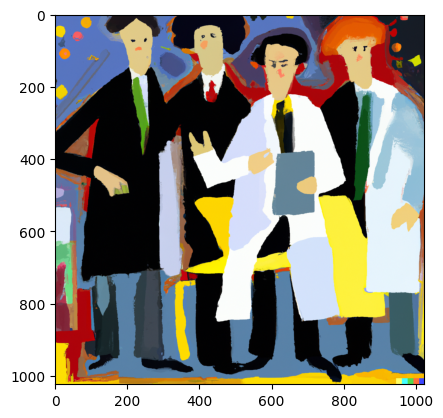

In [ ]:
fig, ax = plt.subplots()
ax.imshow(image)

## Apply Gaussian blur, creating a new image

In [ ]:


blurred3 = ski.filters.gaussian(
   image, sigma=(3, 3), truncate=3.5, channel_axis=-1)

blurred5 = ski.filters.gaussian(
   image, sigma=(5, 5), truncate=5.5, channel_axis=-1)

blurred7 = ski.filters.gaussian(
   image, sigma=(7, 7), truncate=7.5, channel_axis=-1)

## Display blurred image


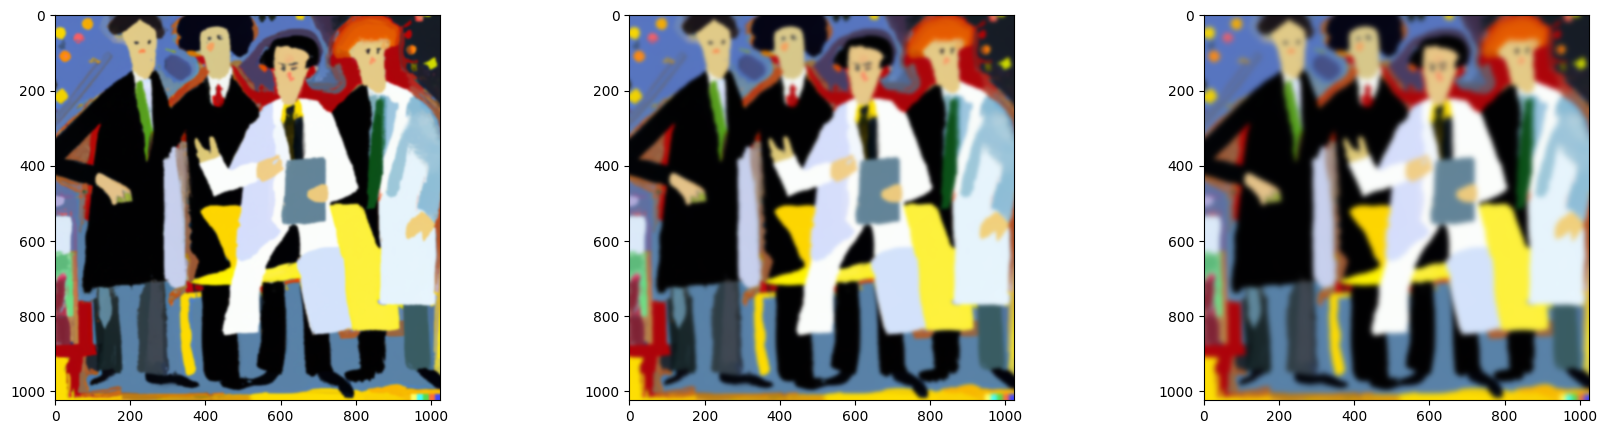

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(21, 5))

ax[0].imshow(blurred3)
ax[1].imshow(blurred5)
ax[2].imshow(blurred7)

# Example. 3D profile

Text(0.5, 0, 'X')

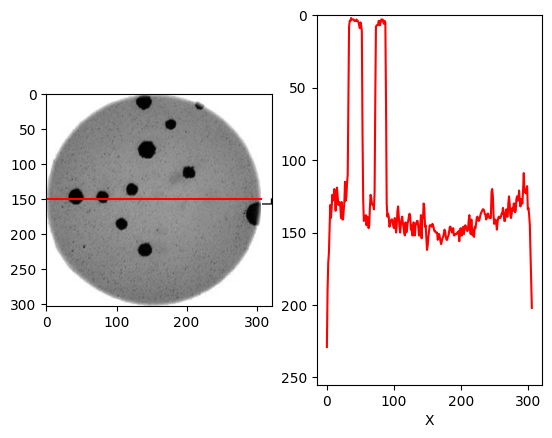

In [ ]:
# read colonies color image and convert to grayscale
image1 = iio.imread('/content/drive/MyDrive/Colab Notebooks/images/colonies-01.tif')

image_gray = ski.color.rgb2gray(image1)

# define the pixels for which we want to view the intensity (profile)
xmin, xmax = (0, image_gray.shape[1])
Y = ymin = ymax = 150

# select the vector of pixels along "Y"
image_gray_pixels_slice = image_gray[Y, :]

# guarantee the intensity values are in the [0:255] range (unsigned integers)
image_gray_pixels_slice = ski.img_as_ubyte(image_gray_pixels_slice)

fig, ax = plt.subplots(1,2)

ax[0].imshow(image_gray, cmap='gray')
ax[0].plot([xmin, xmax], [ymin, ymax], color='red')

ax[1].plot(image_gray_pixels_slice, color='red')
ax[1].set_ylim(255, 0)
ax[1].set_ylabel('L')
ax[1].set_xlabel('X')

# Task: Image Smoothing

In [ ]:
blurred_image5 = ski.filters.gaussian(
   image1, sigma=(5, 5), truncate=5.5, channel_axis=-1)


Text(0.5, 0, 'X')

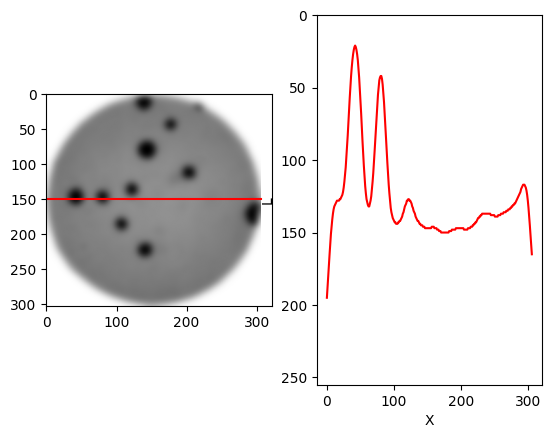

In [ ]:
image_gray_blurred = ski.color.rgb2gray(blurred_image5)

xmin, xmax = (0, image_gray_blurred.shape[1])
Y = ymin = ymax = 150

image_gray_pixels_slice = image_gray_blurred[Y, :]

image_gray_pixels_slice = ski.img_as_ubyte(image_gray_pixels_slice)


fig, ax = plt.subplots(1,2)
ax[0].imshow(image_gray_blurred, cmap='gray')
ax[0].plot([xmin, xmax], [ymin, ymax], color='red')

ax[1].plot(image_gray_pixels_slice, color='red')
ax[1].set_ylim(255, 0)
ax[1].set_ylabel('L')
ax[1].set_xlabel('X')

# Example. Visualizing Smoothing in 3D

In [ ]:
import imageio.v3 as iio
import skimage as ski
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np

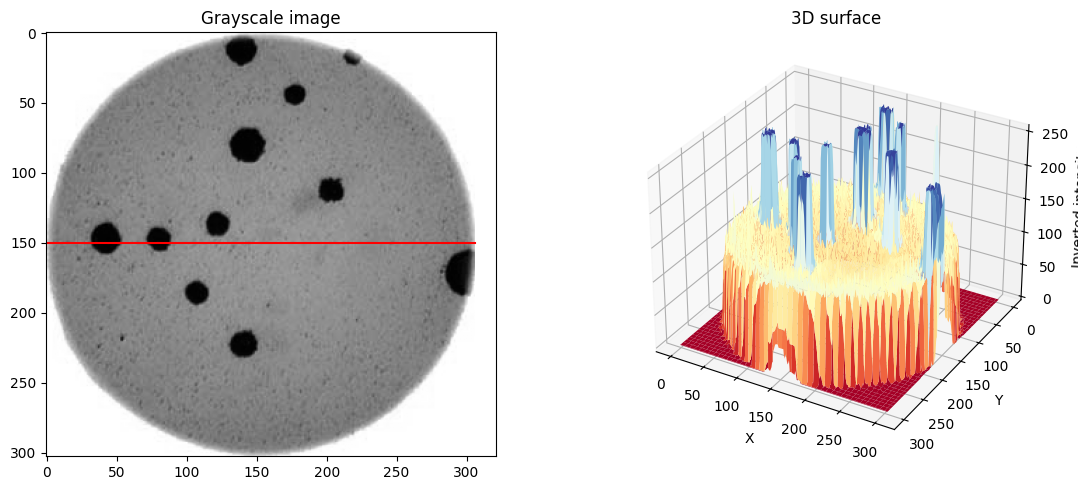

In [ ]:
# read colonies color image and convert to grayscale
image_exmp = iio.imread('/content/drive/MyDrive/Colab Notebooks/images/colonies-01.tif')
image_gray_exmp = ski.color.rgb2gray(image_exmp)

# 8-bit grayscale
image_gray_8bit = ski.img_as_ubyte(image_gray_exmp)
ny, nx = image_gray_8bit.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))

# simple negation (valleys -> ridges)
Z = 255 - image_gray_8bit  # or: Z = -image_gray_8bit

# define the profile line if you still want it
xmin, xmax = (0, nx)
Y_line = ymin = ymax = 150

# create figure with 1 row, 2 columns
fig = plt.figure(figsize=(12, 5))

# 2D subplot
ax0 = fig.add_subplot(1, 2, 1)
ax0.imshow(image_gray_8bit, cmap='gray')
ax0.plot([xmin, xmax], [ymin, ymax], color='red')
ax0.set_title('Grayscale image')

# 3D subplot
ax1 = fig.add_subplot(1, 2, 2, projection='3d')
ax1.plot_surface(X,Y,Z,cmap='RdYlBu',linewidth=0)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Inverted intensity')
ax1.set_title('3D surface')
ax1.invert_yaxis()
plt.tight_layout()
plt.show()

# Task: Selecting σ


In [ ]:
image_col = iio.imread('/content/drive/MyDrive/Colab Notebooks/images/colonies-01.tif')

## Low Sigma

In [ ]:
import cv2

low_sigma = 2
blur_low=cv2.GaussianBlur(image_col,(0,0),low_sigma)


## Mid Sigma

In [ ]:
mid_sigma = 3
blur_mid=cv2.GaussianBlur(image_col,(0,0),mid_sigma)


## High Sigma

In [ ]:
high_sigma = 6

blur_high = cv2.GaussianBlur(image_col, (0, 0), high_sigma)

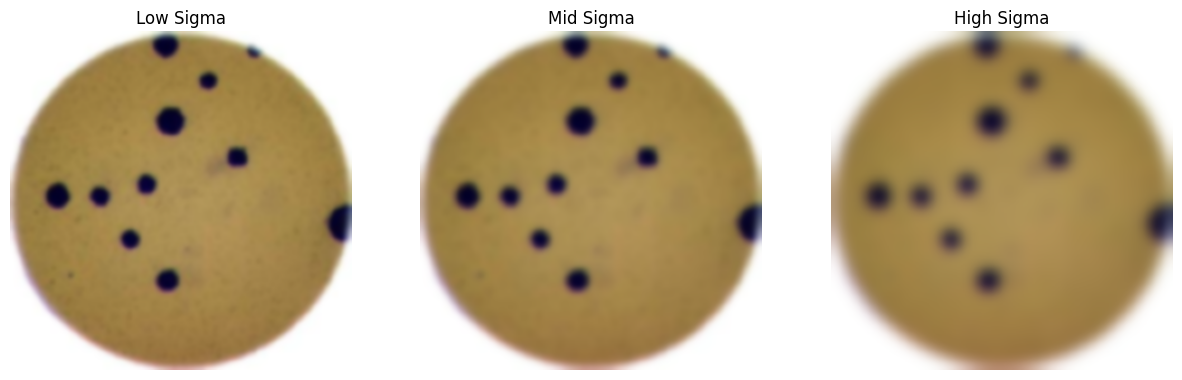

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(blur_low, cmap='gray')
plt.title('Low Sigma')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(blur_mid, cmap='gray')
plt.title('Mid Sigma')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(blur_high, cmap='gray')
plt.title('High Sigma')
plt.axis('off')

plt.show()


# Task: Selecting Kernel Parameters

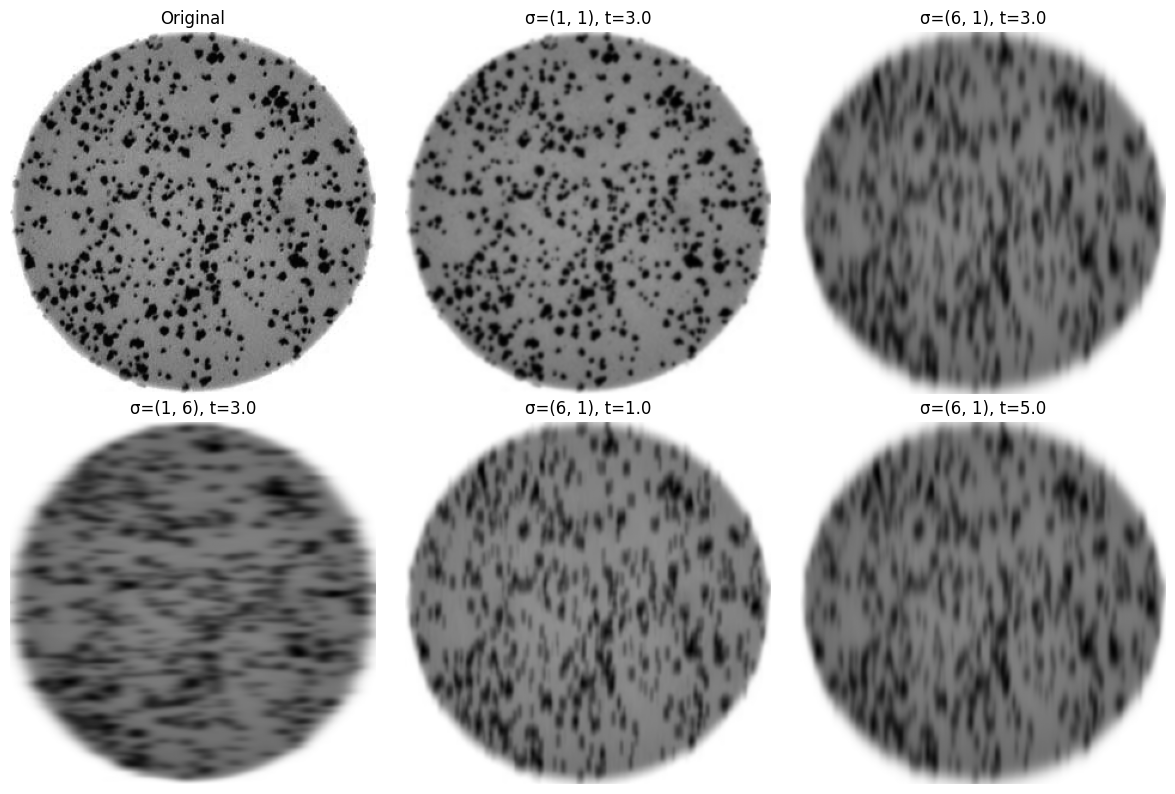

In [ ]:
image = iio.imread(uri="/content/drive/MyDrive/Colab Notebooks/images/colonies-03.tif")
image_gray=ski.color.rgb2gray(image)

settings = [
    ((1,1),3.0),
    ((6,1),3.0),
    ((1,6),3.0),
    ((6,1),1.0),
    ((6,1),5.0)
]

fig, ax = plt.subplots(2,3, figsize=(12,8))
ax = ax.ravel()

ax[0].set_title('Original')
ax[0].imshow(image_gray, cmap='gray')
ax[0].axis('off')

for i, (sigma, trunc) in enumerate(settings, start=1):
  blur = ski.filters.gaussian(image_gray, sigma=sigma, truncate=trunc)
  ax[i].set_title(f'σ={sigma}, t={trunc}')
  ax[i].imshow(blur, cmap='gray')
  ax[i].axis('off')

plt.tight_layout()
plt.show()

## Median filter

Median is great for salt-and-pepper noise because it removes isolated extreme pixels without blurring edges as much.

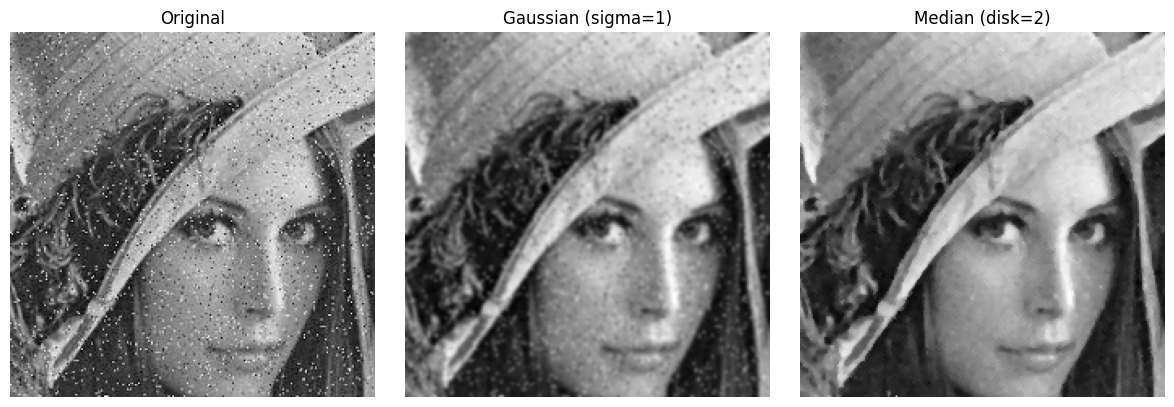

In [ ]:
from skimage.morphology import disk

image_s_p = iio.imread(uri="/content/drive/MyDrive/Colab Notebooks/images/salt_pepper.jpg")
img_sp_gray=ski.color.rgb2gray(image_s_p)

median_blur = ski.filters.median(img_sp_gray, disk(2))
gauss_blur = ski.filters.gaussian(img_sp_gray, sigma=1.0)


fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].set_title("Original")
ax[0].imshow(img_sp_gray, cmap="gray"); ax[0].axis("off")

ax[1].set_title("Gaussian (sigma=1)")
ax[1].imshow(gauss_blur, cmap="gray"); ax[1].axis("off")

ax[2].set_title("Median (disk=2)")
ax[2].imshow(median_blur, cmap="gray"); ax[2].axis("off")

plt.tight_layout()
plt.show()